# 📧 Spam Email Detection
Binary classification of emails (**spam vs. ham**) using TF-IDF features and three classical ML models
(Logistic Regression, LinearSVC, KNN), tuned with `GridSearchCV` and compared with ROC / PR curves, confusion matrices and metric charts.

**Pipeline:** EDA → Cleaning → TF-IDF → Baseline models → Hyper-parameter tuning → Evaluation & interpretation

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC , LinearSVC
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, accuracy_score

from sklearn.metrics import precision_recall_curve, average_precision_score
from wordcloud import WordCloud
from IPython.display import display
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
GREEN, RED = '#2ecc71', '#e74c3c'

**EDA**
---



In [11]:
df = pd.read_csv('emails.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [13]:
df['spam'].value_counts()

,count
spam,
0,4360
1,1368


In [14]:
df['text'][0]

"Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability : your  ma

In [15]:
import nltk
import re
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def removed_stop_words(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

df['new_text'] = df['text'].apply(removed_stop_words)
df['new_text'].head()

,new_text
0,subject naturally irresistible corporate ident...
1,subject stock trading gunslinger fanny merrill...
2,subject unbelievable new homes made easy im wa...
3,subject color printing special request additio...
4,subject money get software cds software compat...


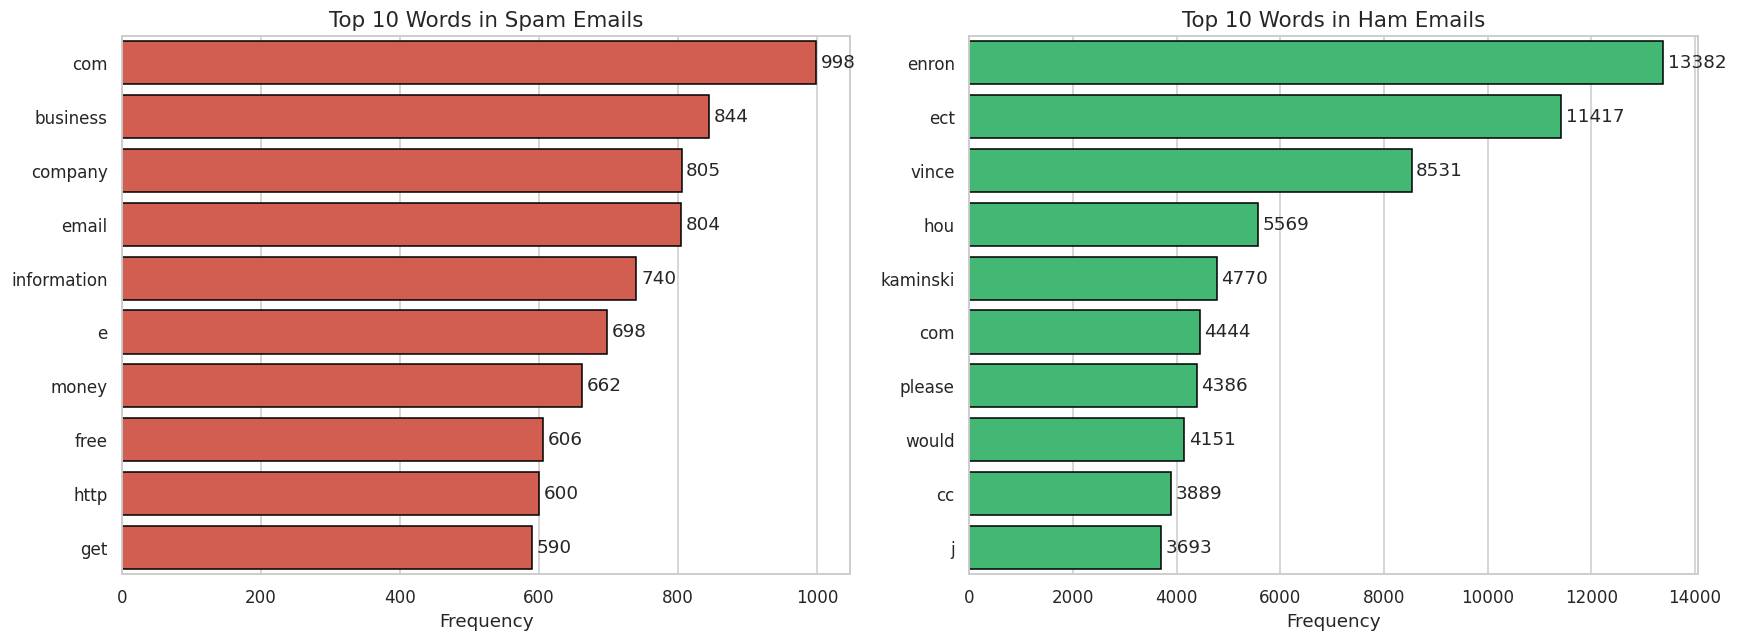

In [ ]:
IGNORE = {'subject', 're', 'fw', 'fwd'}

def top_words(series, n=10):
    counter = Counter(w for t in series for w in t.split() if w not in IGNORE)
    return counter.most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (label, name, color) in zip(axes, [(1, 'Spam', RED), (0, 'Ham', GREEN)]):
    words, counts = zip(*top_words(df.loc[df['spam'] == label, 'new_text']))
    sns.barplot(x=list(counts), y=list(words), color=color, edgecolor='black', ax=ax)
    ax.bar_label(ax.containers[0], padding=3)
    ax.set_title(f'Top 10 Words in {name} Emails', fontsize=14)
    ax.set_xlabel('Frequency')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [18]:
df.duplicated().sum()

np.int64(33)

In [19]:
df.drop_duplicates(inplace=True,ignore_index=True)
df.duplicated().sum()

np.int64(0)

In [20]:
df.isna().sum()

,0
text,0
spam,0
new_text,0


### More EDA visualizations (after removing duplicates)

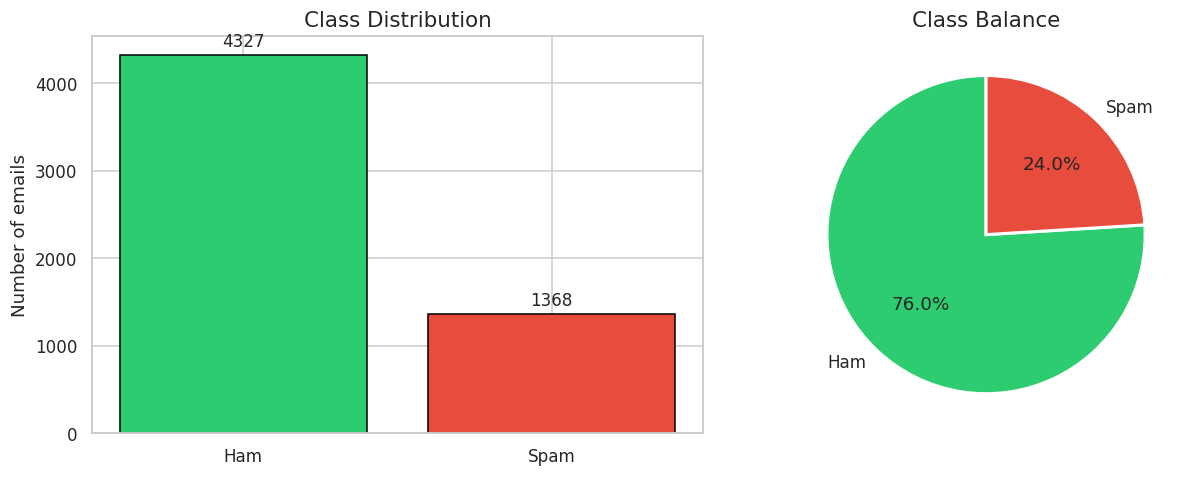

Imbalance ratio (ham : spam) = 3.2 : 1  ->  class_weight="balanced" is used in the models


In [21]:
counts = df['spam'].value_counts().sort_index()
labels = ['Ham', 'Spam']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(labels, counts.values, color=[GREEN, RED], edgecolor='black')
axes[0].bar_label(bars, padding=3, fontsize=11)
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_ylabel('Number of emails')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=[GREEN, RED],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Balance', fontsize=14)

plt.tight_layout()
plt.show()
print(f'Imbalance ratio (ham : spam) = {counts[0] / counts[1]:.1f} : 1  ->  class_weight="balanced" is used in the models')

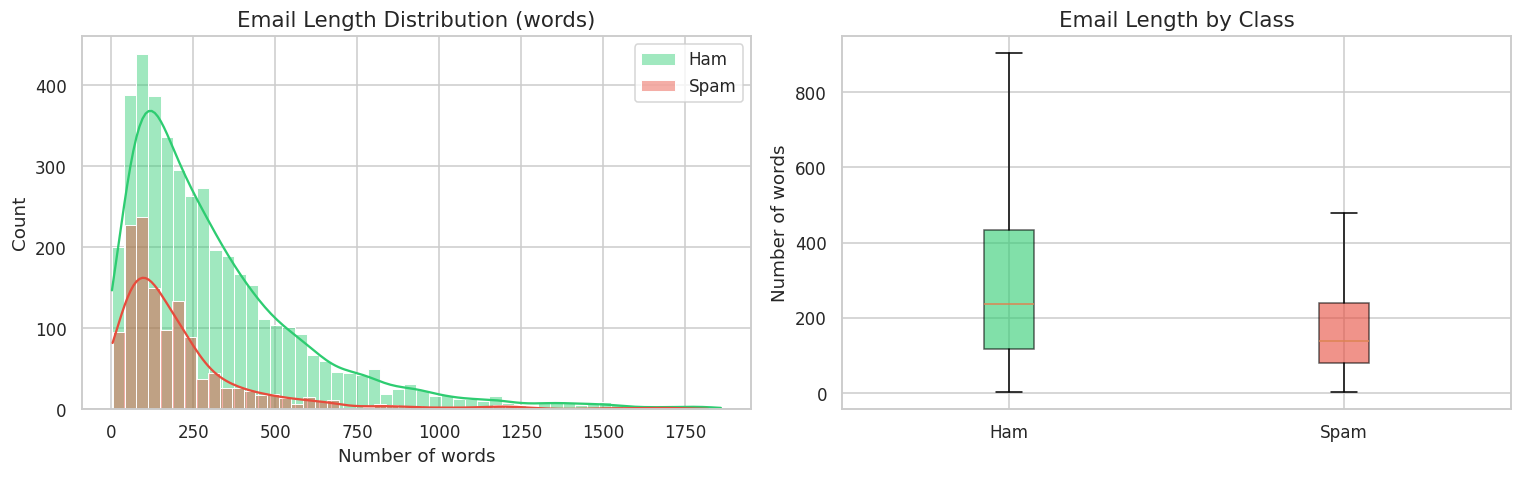

spam
Ham     239.0
Spam    139.5


In [ ]:
df['word_count'] = df['text'].str.split().str.len()
cap = df['word_count'].quantile(0.99)
plot_df = df[df['word_count'] <= cap]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for label, name, color in [(0, 'Ham', GREEN), (1, 'Spam', RED)]:
    sns.histplot(plot_df.loc[plot_df['spam'] == label, 'word_count'], bins=50, kde=True,
                 color=color, alpha=0.45, label=name, ax=axes[0])
axes[0].set_title('Email Length Distribution (words)', fontsize=14)
axes[0].set_xlabel('Number of words')
axes[0].legend()

bp = axes[1].boxplot([plot_df.loc[plot_df['spam'] == 0, 'word_count'],
                      plot_df.loc[plot_df['spam'] == 1, 'word_count']],
                     patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [GREEN, RED]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_xticklabels(['Ham', 'Spam'])
axes[1].set_title('Email Length by Class', fontsize=14)
axes[1].set_ylabel('Number of words')

plt.tight_layout()
plt.show()
print(df.groupby('spam')['word_count'].median().rename({0: 'Ham', 1: 'Spam'}).to_string())

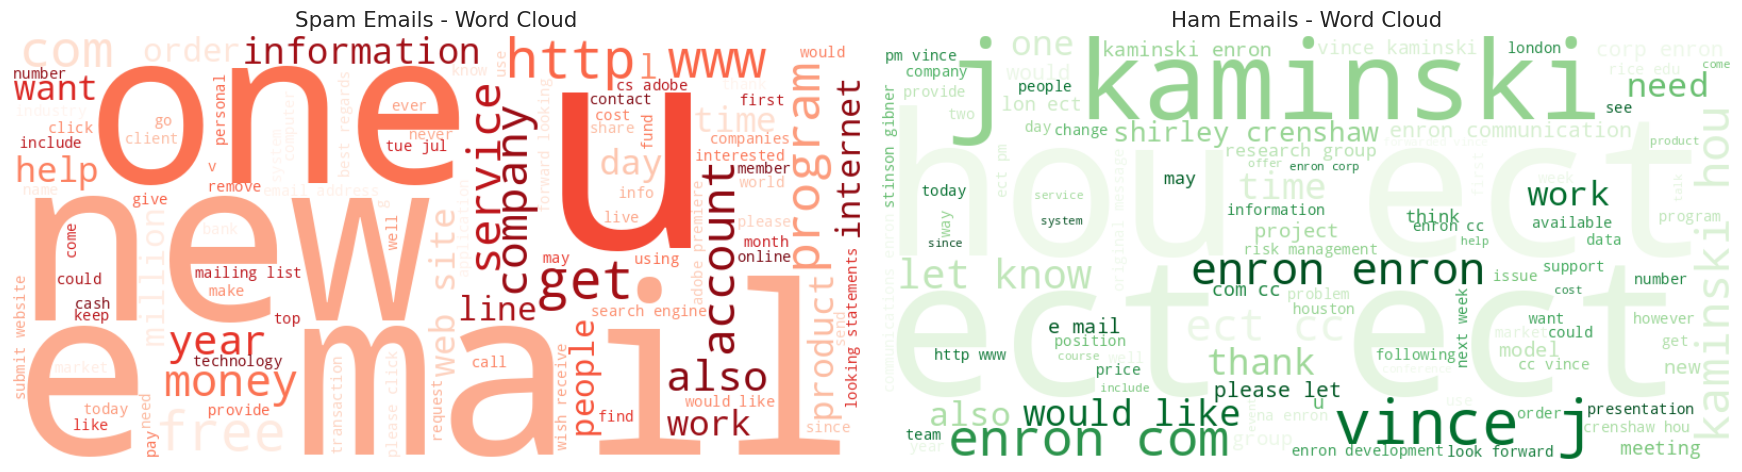

In [23]:
EXTRA_STOP = {'subject', 're', 'fw', 'fwd'}

spam_text = ' '.join(df.loc[df['spam'] == 1, 'new_text'])
ham_text  = ' '.join(df.loc[df['spam'] == 0, 'new_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, text, cmap, name in [(axes[0], spam_text, 'Reds', 'Spam'), (axes[1], ham_text, 'Greens', 'Ham')]:
    cloud = WordCloud(width=800, height=400, background_color='white', colormap=cmap,
                      max_words=100, stopwords=EXTRA_STOP).generate(text)
    ax.imshow(cloud, interpolation='bilinear')
    ax.set_title(f'{name} Emails - Word Cloud', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [24]:
x = df['text']
y = df['spam']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, stratify=y ,random_state=42)

x_train.shape,x_test.shape,y_train.shape,y_test.shape

((4556,), (1139,), (4556,), (1139,))

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english', analyzer='word', ngram_range=(1, 2), min_df=5, max_df=0.8, sublinear_tf=True)

x_train_vectorizer = vectorizer.fit_transform(x_train)
x_test_vectorizer = vectorizer.transform(x_test)

# Modeling

---



In [26]:
model_log = LogisticRegression(C=1, max_iter=1000, random_state=42, class_weight='balanced')
model_log.fit(x_train_vectorizer,y_train)


LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42)

In [27]:
y_valid_pred = cross_val_predict(model_log, x_train_vectorizer, y_train, cv=3, method='predict', n_jobs=-1)

print('Train Accuracy: ', model_log.score(x_train_vectorizer, y_train))
print('Validation Accuracy: ', accuracy_score(y_train, y_valid_pred))
print('Precision Score: ', precision_score(y_train, y_valid_pred))
print('Recall Score: ', recall_score(y_train, y_valid_pred))
print('F1 Score: ', f1_score(y_train, y_valid_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train, y_valid_pred))


Train Accuracy:  0.9958296751536435
Validation Accuracy:  0.9883669885864794
Precision Score:  0.9610274579273693
Recall Score:  0.9917733089579525
F1 Score:  0.9761583445793972
Confusion Matrix: 
 [[3418   44]
 [   9 1085]]


In [28]:
model_linearSVC = LinearSVC(C=1, max_iter=1000, random_state=42, class_weight='balanced')
model_linearSVC.fit(x_train_vectorizer,y_train)

LinearSVC(C=1, class_weight='balanced', random_state=42)

In [29]:
y_valid_pred = cross_val_predict(model_linearSVC, x_train_vectorizer, y_train, cv=3, method='predict', n_jobs=-1)

print('Train Accuracy: ', model_linearSVC.score(x_train_vectorizer, y_train))
print('Validation Accuracy: ', accuracy_score(y_train, y_valid_pred))
print('Precision Score: ', precision_score(y_train, y_valid_pred))
print('Recall Score: ', recall_score(y_train, y_valid_pred))
print('F1 Score: ', f1_score(y_train, y_valid_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train, y_valid_pred))

Train Accuracy:  0.9995610184372257
Validation Accuracy:  0.992756804214223
Precision Score:  0.9880404783808647
Recall Score:  0.9817184643510055
F1 Score:  0.984869325997249
Confusion Matrix: 
 [[3449   13]
 [  20 1074]]


In [30]:
model_knn = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
model_knn.fit(x_train_vectorizer,y_train)

KNeighborsClassifier(metric='cosine', n_jobs=-1, n_neighbors=7)

In [31]:
y_valid_pred = cross_val_predict(model_knn, x_train_vectorizer, y_train, cv=3, method='predict', n_jobs=-1)

print('Train Accuracy: ', model_knn.score(x_train_vectorizer, y_train))
print('Validation Accuracy: ', accuracy_score(y_train, y_valid_pred))
print('Precision Score: ', precision_score(y_train, y_valid_pred))
print('Recall Score: ', recall_score(y_train, y_valid_pred))
print('F1 Score: ', f1_score(y_train, y_valid_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train, y_valid_pred))

Train Accuracy:  0.9925373134328358
Validation Accuracy:  0.9863915715539947
Precision Score:  0.9768946395563771
Recall Score:  0.9661791590493601
F1 Score:  0.9715073529411765
Confusion Matrix: 
 [[3437   25]
 [  37 1057]]


# Fine-Tuning

In [32]:
model_log_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(lowercase=True, stop_words='english', analyzer='word', ngram_range=(1, 2), min_df=5, max_df=0.8, sublinear_tf=True)),
    ('model', LogisticRegression(C=1, max_iter=1000, random_state=42, class_weight='balanced'))
])

param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2), (1,3)],
    'vectorizer__min_df': [2, 5, 10],
    'vectorizer__max_df': [0.7,0.8],
    'model__C': [0.1,1,100]
}

model_log_grid = GridSearchCV(model_log_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
model_log_grid.fit(x_train, y_train)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('vectorizer',
                                        TfidfVectorizer(max_df=0.8, min_df=5,
                                                        ngram_range=(1, 2),
                                                        stop_words='english',
                                                        sublinear_tf=True)),
                                       ('model',
                                        LogisticRegression(C=1,
                                                           class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 100],
                         'vectorizer__max_df': [0.7, 0.8],
                         'vectorizer__min_df': [2, 5, 10],
                         'vectorizer__ngram_range': [(1, 1), (1, 2), (1, 3)]},
             scoring='accuracy')

In [33]:
model_log_grid.best_params_,model_log_grid.best_score_


({'model__C': 100,
  'vectorizer__max_df': 0.7,
  'vectorizer__min_df': 5,
  'vectorizer__ngram_range': (1, 2)},
 np.float64(0.9938544502760092))

In [34]:
model_log_best = model_log_grid.best_estimator_

In [ ]:
model_linearsvc_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(lowercase=True, stop_words='english', analyzer='word', ngram_range=(1, 2), min_df=5, max_df=0.8, sublinear_tf=True)),
    ('model', LinearSVC(C=1, max_iter=10000, random_state=42, class_weight='balanced'))
])
param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'vectorizer__min_df': [2, 5, 10],
    'vectorizer__max_df': [0.7, 0.8],
    'model__C': [0.1, 1, 10]
}

model_linearsvc_grid = GridSearchCV(model_linearsvc_pipeline, param_grid, verbose=1, cv=3, scoring='accuracy', n_jobs=-1)
model_linearsvc_grid.fit(x_train, y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('vectorizer',
                                        TfidfVectorizer(max_df=0.8, min_df=5,
                                                        ngram_range=(1, 2),
                                                        stop_words='english',
                                                        sublinear_tf=True)),
                                       ('model',
                                        LinearSVC(C=1, class_weight='balanced',
                                                  max_iter=10000,
                                                  random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'vectorizer__max_df': [0.7, 0.8],
                         'vectorizer__min_df': [2, 5, 10],
                         'vectorizer__ngram_range': [(1, 1), (1, 2), (1, 3)]},
             scoring='accuracy', verbose=1)

In [36]:
model_linearsvc_grid.best_params_,model_linearsvc_grid.best_score_

({'model__C': 10,
  'vectorizer__max_df': 0.7,
  'vectorizer__min_df': 2,
  'vectorizer__ngram_range': (1, 1)},
 np.float64(0.9938547393967149))

In [37]:
model_linearsvc_best = model_linearsvc_grid.best_estimator_

In [38]:
model_knn_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(lowercase=True, stop_words='english', analyzer='word', ngram_range=(1, 2), min_df=5, max_df=0.8, sublinear_tf=True)),
    ('model', KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm= 'auto'))
])

param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2), (1,3)],
    'vectorizer__min_df': [2, 5, 10],
    'vectorizer__max_df': [0.7,0.8],
    'model__n_neighbors': [3,5,7,9],
    'model__weights': ['uniform', 'distance']
}

model_knn_grid = GridSearchCV(model_knn_pipeline, param_grid, verbose=1, cv=3, scoring='accuracy', n_jobs=-1)
model_knn_grid.fit(x_train, y_train)

Fitting 3 folds for each of 144 candidates, totalling 432 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('vectorizer',
                                        TfidfVectorizer(max_df=0.8, min_df=5,
                                                        ngram_range=(1, 2),
                                                        stop_words='english',
                                                        sublinear_tf=True)),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'model__n_neighbors': [3, 5, 7, 9],
                         'model__weights': ['uniform', 'distance'],
                         'vectorizer__max_df': [0.7, 0.8],
                         'vectorizer__min_df': [2, 5, 10],
                         'vectorizer__ngram_range': [(1, 1), (1, 2), (1, 3)]},
             scoring='accuracy', verbose=1)

In [39]:
model_knn_grid.best_params_,model_knn_grid.best_score_

({'model__n_neighbors': 5,
  'model__weights': 'distance',
  'vectorizer__max_df': 0.7,
  'vectorizer__min_df': 2,
  'vectorizer__ngram_range': (1, 1)},
 np.float64(0.9901232030063928))

In [40]:
model_knn_best = model_knn_grid.best_estimator_

### Model comparison
ROC and Precision-Recall curves (3-fold cross-validated scores on the training set) for the three tuned models.

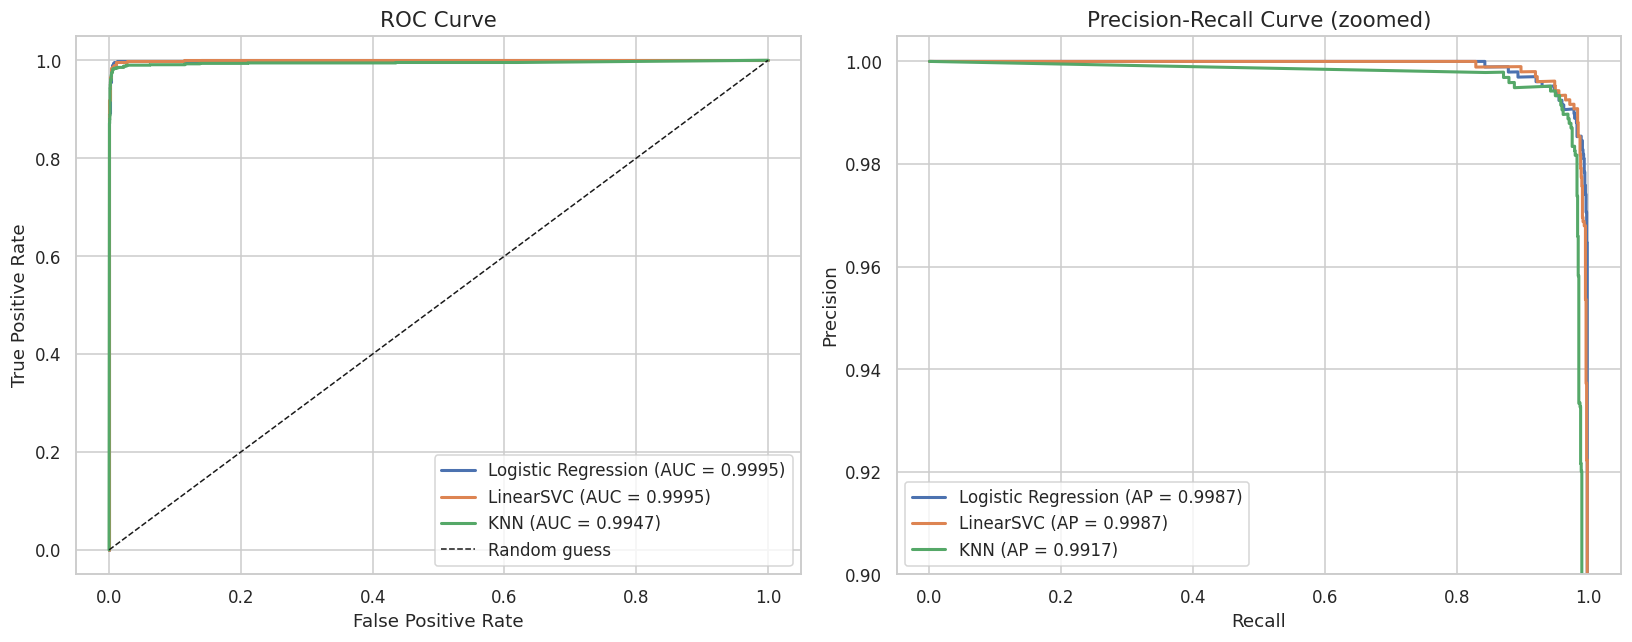

In [ ]:
scores = {
    'Logistic Regression': cross_val_predict(model_log_best, x_train, y_train, cv=3, method='predict_proba', n_jobs=-1)[:, 1],
    'LinearSVC':           cross_val_predict(model_linearsvc_best, x_train, y_train, cv=3, method='decision_function', n_jobs=-1),
    'KNN':                 cross_val_predict(model_knn_best, x_train, y_train, cv=3, method='predict_proba', n_jobs=-1)[:, 1],
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, s in scores.items():
    fpr, tpr, _ = roc_curve(y_train, s)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_score(y_train, s):.4f})')

    prec, rec, _ = precision_recall_curve(y_train, s)
    axes[1].plot(rec, prec, lw=2, label=f'{name} (AP = {average_precision_score(y_train, s):.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=14)
axes[0].legend(loc='lower right')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_ylim(0.9, 1.005)
axes[1].set_title('Precision-Recall Curve (zoomed)', fontsize=14)
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

### Final evaluation on the held-out test set

In [42]:
y_valid_pred = cross_val_predict(model_linearsvc_best, x_train, y_train, cv=3, method='predict', n_jobs=-1)

print('Train Accuracy: ', model_linearsvc_best.score(x_train, y_train))
print('Validation Accuracy: ', accuracy_score(y_train, y_valid_pred))
print('Precision Score: ', precision_score(y_train, y_valid_pred))
print('Recall Score: ', recall_score(y_train, y_valid_pred))
print('F1 Score: ', f1_score(y_train, y_valid_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train, y_valid_pred))


Train Accuracy:  1.0
Validation Accuracy:  0.9938542581211589
Precision Score:  0.990791896869245
Recall Score:  0.9835466179159049
F1 Score:  0.9871559633027523
Confusion Matrix: 
 [[3452   10]
 [  18 1076]]


In [43]:
y_test_pred = model_linearsvc_best.predict(x_test)

print('Test Accuracy: ', model_linearsvc_best.score(x_test, y_test))
print('Precision Score: ', precision_score(y_test, y_test_pred))
print('Recall Score: ', recall_score(y_test, y_test_pred))
print('F1 Score: ', f1_score(y_test, y_test_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test, y_test_pred))



Test Accuracy:  0.9956101843722563
Precision Score:  0.9890909090909091
Recall Score:  0.9927007299270073
F1 Score:  0.9908925318761385
Confusion Matrix: 
 [[862   3]
 [  2 272]]


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.9947,0.9855,0.9927,0.9891
LinearSVC,0.9956,0.9891,0.9927,0.9909
KNN,0.9860,0.9640,0.9781,0.9710


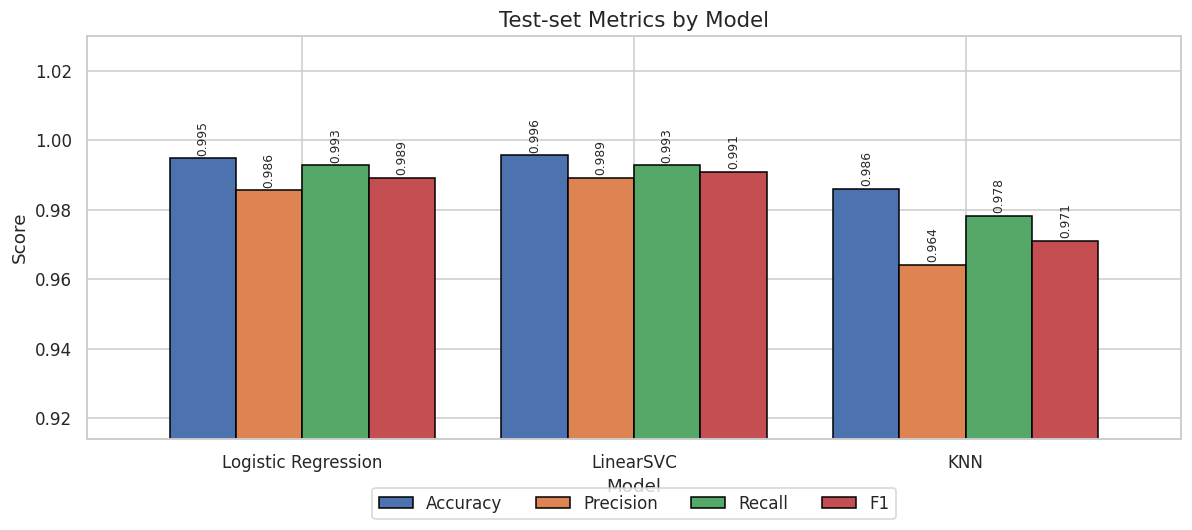

In [44]:
tuned_models = {
    'Logistic Regression': model_log_best,
    'LinearSVC': model_linearsvc_best,
    'KNN': model_knn_best,
}

rows, test_preds = [], {}
for name, m in tuned_models.items():
    pred = m.predict(x_test)
    test_preds[name] = pred
    rows.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1':        f1_score(y_test, pred),
    })

results_df = pd.DataFrame(rows).set_index('Model')
display(results_df.round(4))

ax = results_df.plot(kind='bar', figsize=(11, 5), rot=0, edgecolor='black', width=0.8)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2, fontsize=8, rotation=90)
ax.set_ylim(max(0, results_df.min().min() - 0.05), 1.03)
ax.set_title('Test-set Metrics by Model', fontsize=14)
ax.set_ylabel('Score')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)
plt.tight_layout()
plt.show()

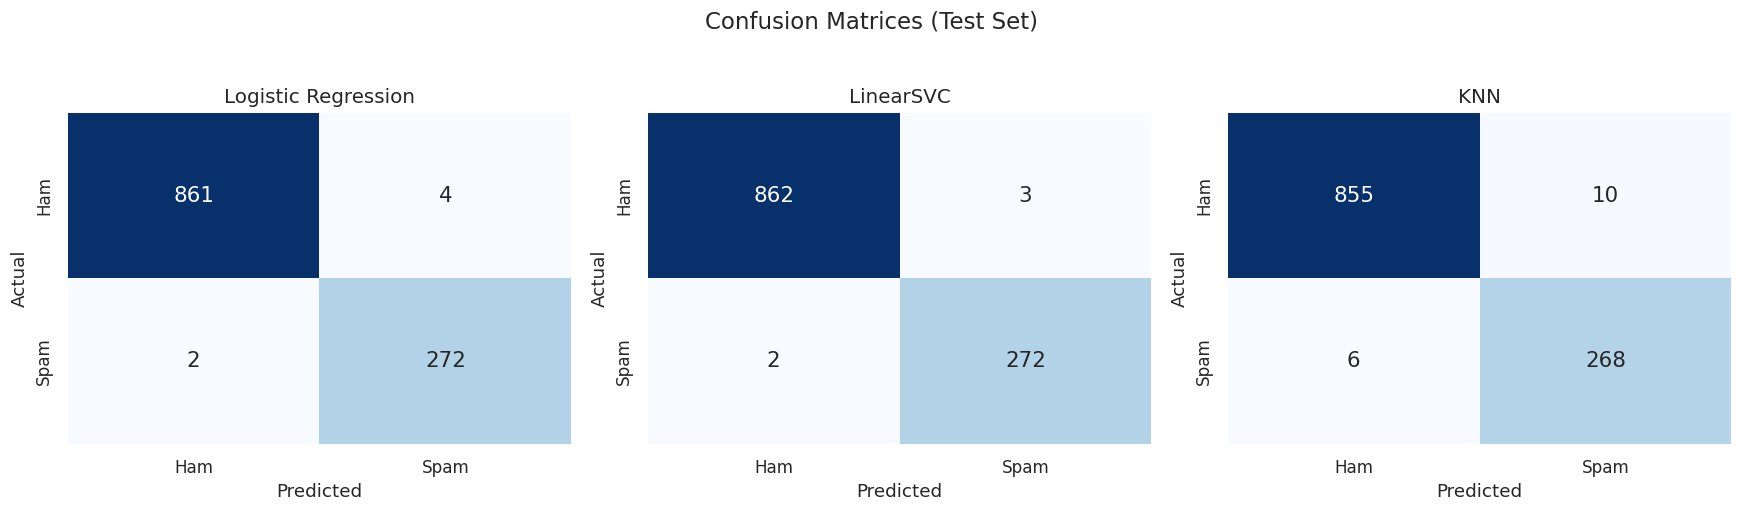

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, pred) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax, annot_kws={'size': 14},
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices (Test Set)', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

### What does the final model look at?
Words with the largest positive weights push an email towards **spam**, the most negative towards **ham**.

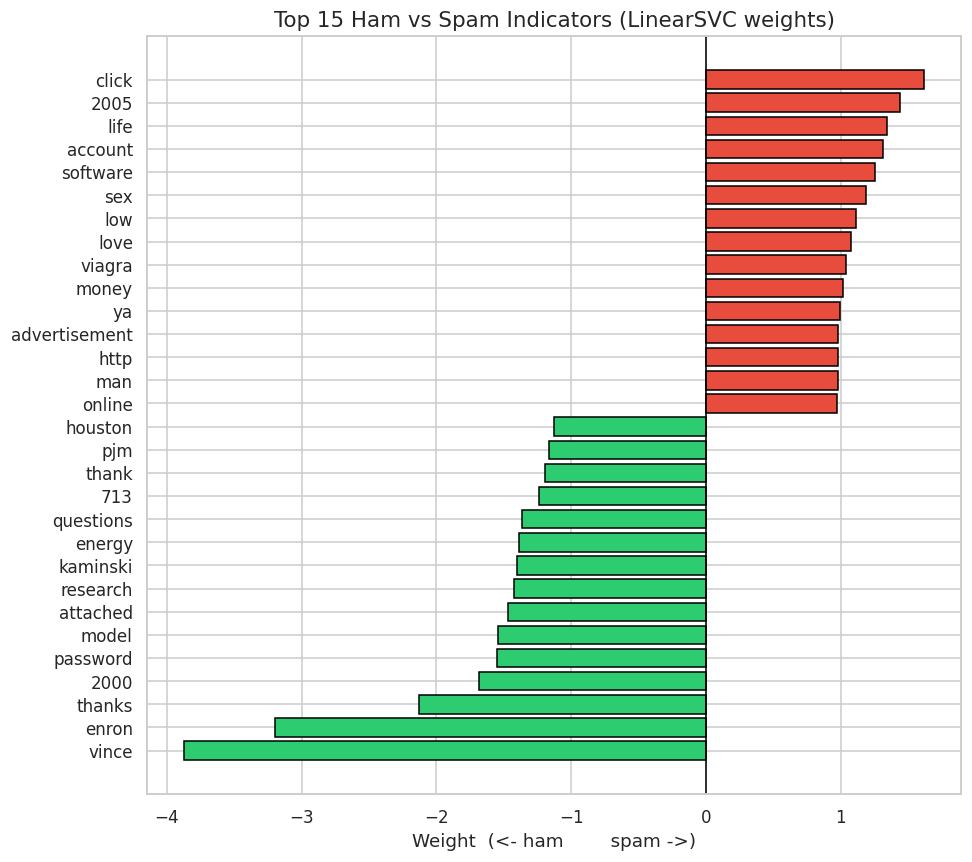

In [46]:
vec = model_linearsvc_best.named_steps['vectorizer']
clf = model_linearsvc_best.named_steps['model']

feature_names = np.array(vec.get_feature_names_out())
coefs = clf.coef_.ravel()

top_n = 15
order = np.argsort(coefs)
idx = np.concatenate([order[:top_n], order[-top_n:]])    # most ham-like ... most spam-like

plt.figure(figsize=(9, 8))
plt.barh(feature_names[idx], coefs[idx], color=[GREEN] * top_n + [RED] * top_n, edgecolor='black')
plt.axvline(0, color='black', lw=1)
plt.title(f'Top {top_n} Ham vs Spam Indicators (LinearSVC weights)', fontsize=14)
plt.xlabel('Weight  (<- ham        spam ->)')
plt.tight_layout()
plt.show()

In [47]:
spam_email = """Congratulations! You have been selected to receive a $1,000 cash prize. Claim your reward now by clicking the link below. This exclusive offer expires today, so act fast! You are one of the lucky winners. Click here to claim your FREE prize now."""

ham_email = """Hi Ahmed, I wanted to remind you that our project meeting is scheduled for tomorrow at 10 AM. Please bring the updated report and let me know if you have any questions before the meeting. Thanks, and see you tomorrow."""

print(model_linearsvc_best.predict([spam_email]))
print(model_linearsvc_best.predict([ham_email]))

[1]
[0]


In [ ]:
def predict_email(text):
    """Classify one email and show how confident the LinearSVC model is (distance from the decision boundary)."""
    score = model_linearsvc_best.decision_function([text])[0]
    label = 'SPAM' if score > 0 else 'HAM'
    print(f'{label}  |  decision score = {score:+.3f}')

predict_email(spam_email)
predict_email(ham_email)

SPAM 🚫  |  decision score = +1.079
HAM ✅  |  decision score = -1.558


## ✅ Summary
- Cleaned the data (duplicates removed, no missing values) and explored class balance, email length and the most frequent words.
- Built TF-IDF (1-2 grams) features and compared **Logistic Regression, LinearSVC and KNN**.
- Tuned each model with `GridSearchCV` (3-fold) and compared them using ROC / PR curves, confusion matrices and test-set metrics.
- Interpreted the final model by inspecting the words that push an email towards spam or ham.